# MPC with MSA NARX Model

In [ ]:
# Cell 1 -- Imports & Model loading

import os
os.environ['OMP_NUM_THREADS'] = '1' # Set before torch import
os.environ['MKL_NUM_THREADS'] = '1'

import sys, time
sys.path.insert(0, os.path.abspath('../..'))
sys.path.insert(0, os.path.abspath('.'))

import torch, numpy as np, yaml, h5py
import matplotlib.pyplot as plt

torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

from mpc_msa_utils import load_scaler, warmstart_shift, solve_msa_step
from common.mpc_common import NARXWindowManager

MODEL_DIR = '../training/Models_MSA/version_3'
msa_model = torch.load(f'{MODEL_DIR}/narx_model_full.pt', map_location='cpu', weights_only=False)
msa_model.eval()

feat_scaler = load_scaler(f'{MODEL_DIR}/msa_feature_scaler.yml')
label_scaler    = load_scaler(f'{MODEL_DIR}/label_scaler.yml')
inp_feat_scaler = load_scaler(f'{MODEL_DIR}/input_feature_scaler.yml')

with open(f'{MODEL_DIR}/model_metadata.yml') as f:
    _mm = yaml.safe_load(f)
metadata = _mm['dataset_metadata']

M = 15
print('torch threads:', torch.get_num_threads(), '| interop:', torch.get_num_interop_threads())
print(f'MSA model: {sum(p.numel() for p in msa_model.parameters()):,} params | M={M}')

torch threads: 1 | interop: 1
MSA model: 2,223,110 params | M=15


In [2]:
# Cell 2 -- MPC Hyperparams

T_sp = 330.0 # Reactor setpoint
Q_track = 10.0 # Tracking weight

R_energy = 1.0 # Heating power penalty weight
R_du = 1.0 # Control rate penalty
MAX_ITER = 100 # L-BFGS iter per step

FLOW_MEAN_SC = 0.0

# Sanity Check --
T_sp_sc_check = (T_sp - label_scaler['mean'][0]) / label_scaler['std'][0]
print(f'T_sp = {T_sp} K  ->  scaled = {T_sp_sc_check:.3f}  (expect ~O(1))')

# Scaled bounds (reference)
T_min_sc = (292.0 - inp_feat_scaler['mean'][1:9]) / inp_feat_scaler['std'][1:9]
T_max_sc = (365.0 - inp_feat_scaler['mean'][1:9]) / inp_feat_scaler['std'][1:9]
print(f'T_setpoint bounds (scaled):  min ~{T_min_sc.mean():.2f}  max ~{T_max_sc.mean():.2f}')

T_sp = 330.0 K  ->  scaled = -1.058  (expect ~O(1))
T_setpoint bounds (scaled):  min ~-3.08  max ~3.06


In [3]:
# Cell 3 -- CL Sim

DATASET_PATH = '../../Data_Sampling/datasets/21_05_2026/narx/thermal_narx_dataset_3.h5'
with h5py.File(DATASET_PATH, 'r') as f:
    x0_window_phys = f['narx_state_features'][-1, :].astype(np.float64)

# Scale the NARX window --
narx_mean = feat_scaler['mean'][:3796]
narx_std = feat_scaler['std'][:3796]
x0_window_sc = (x0_window_phys - narx_mean) / narx_std

win_mgr = NARXWindowManager(metadata)
win_mgr.window = x0_window_sc.copy()

print(f'Initial window: mean={x0_window_sc.mean():.3f}  std={x0_window_sc.std():.3f}  (sane if std ~O(1))')

N_SIM = 100
x_log, u_log, y_log, obj_log, t_log = [], [], [], [], []
U_warm = None # init

for k in range(N_SIM):
    x_sc = win_mgr.get_window()
    flow_future_sc = np.full(M-1, FLOW_MEAN_SC)

    _t0 = time.time()
    u_next_sc, U_opt_sc, obj_val = solve_msa_step(
        msa_model = msa_model,
        x_current_sc = x_sc,
        flow_future_sc= flow_future_sc,
        feat_scaler= feat_scaler,
        label_scaler= label_scaler,
        inp_feat_scaler= inp_feat_scaler,
        T_sp= T_sp,
        Q_track= Q_track,
        R_energy= R_energy,
        R_du= R_du,
        U_warm= U_warm,
        M= M,
        max_iter= MAX_ITER,
    )
    _dt = time.time()
    print(f'[step {k:3d}] obj={obj_val:.2f}  t={_dt:.2f}s', flush=True)

    # Warm-start aka future covariates --
    U_warm = warmstart_shift(U_opt_sc, n_steps=M-1, n_setpt=8)
    
    # MSA h=1 prediction -- NARX window update
    # Full covariate block --
    flow_sc_k1 = float(flow_future_sc[0])
    U_full_np = np.stack([
        np.concatenate([[flow_future_sc[i]], U_opt_sc[i*8:(i+1)*8]])
        for i in range(M - 1)
    ]).flatten()                                        # (126,)

    msa_in_sc = np.concatenate([x_sc, U_full_np])        # (3922,)
    with torch.no_grad():
        y_msa_sc = msa_model(
            torch.tensor(msa_in_sc.reshape(1, -1), dtype=torch.float32)
        ).numpy().reshape(M, 26)                          # (M, 26) scaled
    y_h1_sc = y_msa_sc[0]                                # (26,) h=1 prediction

    # Update rolling NARX window
    win_mgr.update(y_h1_sc, u_next_sc, flow_sc_k1, metadata['labels'])

    x_log.append(x_sc.copy())
    u_log.append(u_next_sc.copy())
    y_log.append(y_h1_sc.copy())
    obj_log.append(obj_val)
    t_log.append(_dt)

print(f'\nDone.  Mean step: {np.mean(t_log):.2f}s  |  Total: {sum(t_log):.1f}s')

Initial window: mean=0.414  std=0.741  (sane if std ~O(1))
[step   0] obj=70.56  t=1781249720.11s
[step   1] obj=65.94  t=1781249720.48s
[step   2] obj=63.17  t=1781249720.73s
[step   3] obj=60.38  t=1781249721.26s
[step   4] obj=57.97  t=1781249721.51s
[step   5] obj=55.59  t=1781249721.78s
[step   6] obj=48.93  t=1781249722.16s
[step   7] obj=44.95  t=1781249722.55s
[step   8] obj=38.32  t=1781249722.65s
[step   9] obj=34.59  t=1781249723.01s
[step  10] obj=30.02  t=1781249723.22s
[step  11] obj=26.88  t=1781249723.43s
[step  12] obj=23.26  t=1781249723.72s
[step  13] obj=20.20  t=1781249724.04s
[step  14] obj=17.94  t=1781249724.51s
[step  15] obj=15.25  t=1781249724.76s
[step  16] obj=12.62  t=1781249725.26s
[step  17] obj=10.72  t=1781249725.55s
[step  18] obj=9.25  t=1781249725.80s
[step  19] obj=7.51  t=1781249726.06s
[step  20] obj=6.24  t=1781249726.32s
[step  21] obj=5.52  t=1781249726.62s
[step  22] obj=4.87  t=1781249726.78s
[step  23] obj=4.44  t=1781249726.98s
[step  24] 

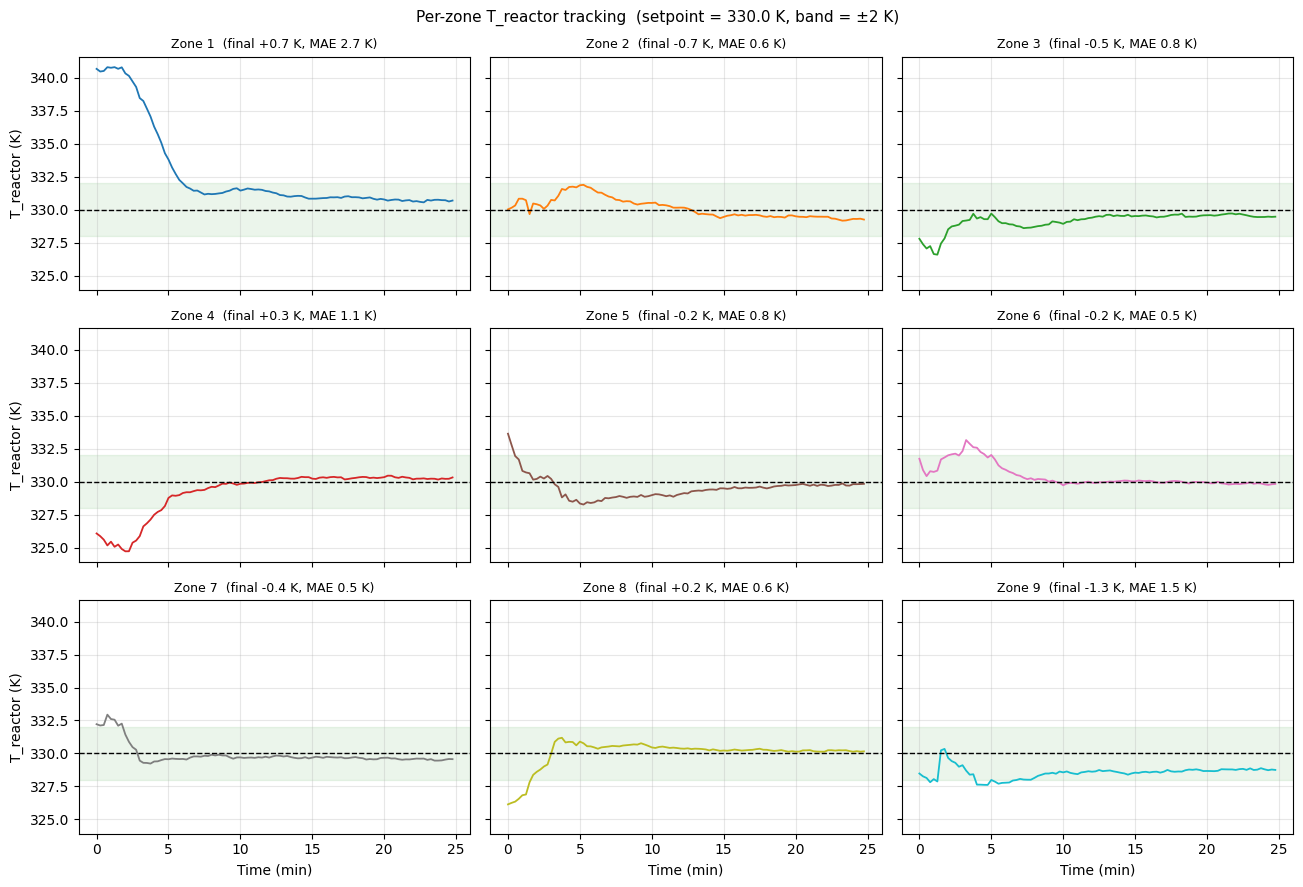

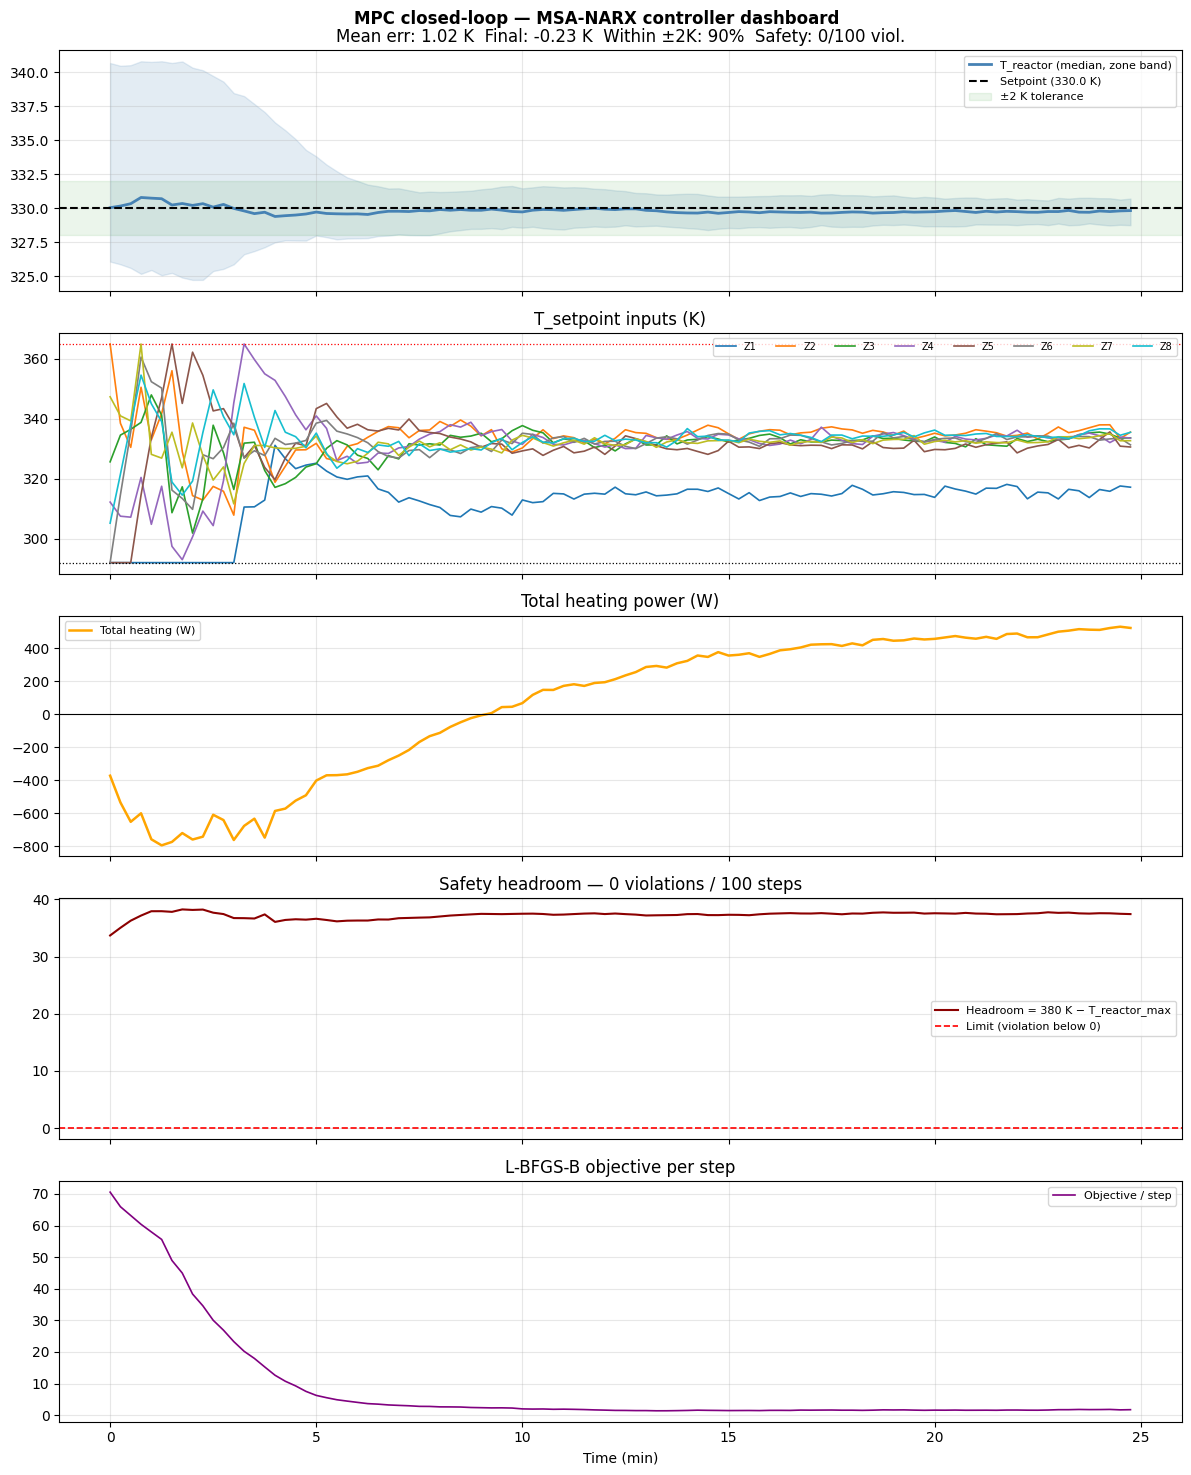

Mean absolute tracking error per zone (K):
  Zone 1: 2.708 K
  Zone 2: 0.635 K
  Zone 3: 0.833 K
  Zone 4: 1.056 K
  Zone 5: 0.770 K
  Zone 6: 0.531 K
  Zone 7: 0.537 K
  Zone 8: 0.636 K
  Zone 9: 1.474 K

Overall mean:   1.020 K  (0.31%)
Final offset:   -0.234 K
T_reactor_max:  346.31 K  (bound: 380 K)
Safety violations: 0 / 100
Total energy:   24.7 Wh
Mean step time: 1781249734.30 s  |  Total: 178124973429.9 s


In [4]:
# Cell 4: Plotting

u_arr = np.array(u_log)    # (N_SIM, 8)  scaled T_setpoints
y_arr = np.array(y_log)    # (N_SIM, 26) scaled h=1 predictions
t_ax  = np.arange(N_SIM) * 15.0 / 60.0   # time axis in minutes

# Unscale
T_react_phys = y_arr[:, 0:9]   * label_scaler['std'][0:9]   + label_scaler['mean'][0:9]
T_therm_phys = y_arr[:, 9:17]  * label_scaler['std'][9:17]  + label_scaler['mean'][9:17]
heat_phys    = y_arr[:, 17:25] * label_scaler['std'][17:25] + label_scaler['mean'][17:25]
T_max_phys   = y_arr[:, 25]    * label_scaler['std'][25]    + label_scaler['mean'][25]
T_set_phys   = u_arr * inp_feat_scaler['std'][1:9] + inp_feat_scaler['mean'][1:9]

tracking_err = T_react_phys - T_sp
colors9 = plt.cm.tab10(np.linspace(0, 1, 9))
colors8 = plt.cm.tab10(np.linspace(0, 1, 8))

# ── Per-zone tracking grid ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    mae   = np.abs(tracking_err[:, i]).mean()
    final = tracking_err[-1, i]
    ax.plot(t_ax, T_react_phys[:, i], color=colors9[i], linewidth=1.3)
    ax.axhline(T_sp, color='black', linestyle='--', linewidth=1.0)
    ax.axhspan(T_sp - 2, T_sp + 2, alpha=0.08, color='green')
    ax.set_title(f'Zone {i+1}  (final {final:+.1f} K, MAE {mae:.1f} K)', fontsize=9)
    ax.grid(True, alpha=0.3)
    if i >= 6: ax.set_xlabel('Time (min)')
    if i % 3 == 0: ax.set_ylabel('T_reactor (K)')
fig.suptitle(f'Per-zone T_reactor tracking  (setpoint = {T_sp} K, band = ±2 K)', fontsize=11)
plt.tight_layout(); plt.savefig('mpc_msa_tracking_grid.png', dpi=150); plt.show()

# ── Dashboard ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

ax = axes[0]
med = np.median(T_react_phys, axis=1)
ax.fill_between(t_ax, T_react_phys.min(1), T_react_phys.max(1), alpha=0.15, color='steelblue')
ax.plot(t_ax, med, color='steelblue', linewidth=2, label='T_reactor (median, zone band)')
ax.axhline(T_sp, color='black', linestyle='--', linewidth=1.5, label=f'Setpoint ({T_sp} K)')
ax.axhspan(T_sp - 2, T_sp + 2, alpha=0.08, color='green', label='±2 K tolerance')
mean_e = np.abs(tracking_err).mean()
pct_in = (np.abs(tracking_err) <= 2).mean() * 100
ax.set_title(f'Mean err: {mean_e:.2f} K  Final: {tracking_err[-1].mean():+.2f} K  '
             f'Within ±2K: {pct_in:.0f}%  Safety: {int((T_max_phys>380).sum())}/{N_SIM} viol.')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
for i in range(8): ax.plot(t_ax, T_set_phys[:, i], color=colors8[i], lw=1.2, label=f'Z{i+1}')
ax.axhline(292, color='black', linestyle=':', lw=0.9); ax.axhline(365, color='red', linestyle=':', lw=0.9)
ax.set_title('T_setpoint inputs (K)'); ax.legend(ncol=8, fontsize=7); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(t_ax, heat_phys.sum(1), color='orange', lw=1.8, label='Total heating (W)')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Total heating power (W)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[3]
headroom = 380.0 - T_max_phys
ax.plot(t_ax, headroom, color='darkred', lw=1.5, label='Headroom = 380 K − T_reactor_max')
ax.axhline(0, color='red', linestyle='--', lw=1.2, label='Limit (violation below 0)')
ax.fill_between(t_ax, headroom, 0, where=(headroom < 0), color='red', alpha=0.3)
ax.set_title(f'Safety headroom — {int((headroom<0).sum())} violations / {N_SIM} steps')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[4]
ax.plot(t_ax, obj_log, color='purple', lw=1.2, label='Objective / step')
ax.set_title('L-BFGS-B objective per step'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlabel('Time (min)')

fig.suptitle('MPC closed-loop — MSA-NARX controller dashboard', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('mpc_msa_dashboard.png', dpi=150); plt.show()

# ── Summary ─────────────────────────────────────────────────────────────────
mean_abs = np.abs(tracking_err).mean(axis=0)
print('Mean absolute tracking error per zone (K):')
for i, e in enumerate(mean_abs):
    print(f'  Zone {i+1}: {e:.3f} K')
print(f'\nOverall mean:   {mean_abs.mean():.3f} K  ({mean_abs.mean()/T_sp*100:.2f}%)')
print(f'Final offset:   {tracking_err[-1].mean():+.3f} K')
print(f'T_reactor_max:  {T_max_phys.max():.2f} K  (bound: 380 K)')
print(f'Safety violations: {int((T_max_phys>380).sum())} / {N_SIM}')
print(f'Total energy:   {heat_phys.sum()*15/3600:.1f} Wh')
print(f'Mean step time: {np.mean(t_log):.2f} s  |  Total: {sum(t_log):.1f} s')
